# Mathematical Engineering — Financial Engineering, FY 2025-2026

## Buy Side, Lab 4b — Risk-Based Allocation Strategies

This notebook implements and analyses risk-based allocation strategies on the Euro Stoxx 50 universe with monthly rebalancing and a 2-year rolling estimation window.

**Outline** 

0. Setup & rolling estimators
1. Part I — Equal Risk Contribution (ERC)
2. Part II — Hierarchical Risk Parity (HRP):
   1. Detoning intuition
   2. Cluster stability across rebalances (Rand index)
   3. Sensitivity to clustering choice and to the volatility allocation scheme
3. Part III — Connecting the dots: ERC vs HRP head-to-head and the role of shrinkage


## 0. Setup


In [41]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.metrics import rand_score

from utilities.backtest import backtest, portfolio_returns
from utilities.covariance_utilities import (
    prepare_rolling_estimation_window,
    covariance_to_correlation,
    risk_contribution,
)
from utilities.hierarchical_clustering import hierarchical_clustering
from utilities.hierarchical_risk_parity import (
    correlation_to_hrp_distance,
    dendrogram_iteration,
    hierarchical_risk_parity,
    recursive_bisection,
)
from utilities.portfolio_optimization import (
    equal_risk_contribution_portfolio,
    inverse_volatility_portfolio,
)
from utilities.principal_component_analysis import (
    detone,
    principal_component_analysis,
)
from utilities.shrinkage import constant_corr_shrinkage, market_factor_shrinkage


In [42]:
# Read prices, compute daily simple returns
data_path = Path("data")
last_prices = pd.read_csv(
    data_path / "sx5e_underlyings.csv", index_col="Date", parse_dates=True
)
performance = last_prices.pct_change().iloc[1:]

In [43]:
# Estimation parameters
estimation_window = 2*252  # error (was 252 but need 2y estimation window)
min_coverage = 0.95  # asset must have >=95% non-NaN in the window
trading_days = 252

# Rebalance on the last trading day of each month
rebalance_dates = pd.DatetimeIndex(
    performance.groupby(pd.Grouper(freq="ME"))
    .apply(lambda x: x.index[-1] if len(x) > 0 else None)
    .dropna()
    .values
)


## 1. Pre-computation: rolling covariance estimators

For each rebalance date we estimate three covariance matrices on the trailing 2-year window:

- **sample** — plain `cov()`,
- **constant_corr** — Ledoit–Wolf (2003) constant-correlation shrinkage,
- **mkt_factor** — Ledoit–Wolf (2002) single-factor shrinkage with the
  equally-weighted return of the surviving universe used as the market
  proxy.

The asset universe at every rebalance is restricted to names with
≥95% non-missing observations in the window.


In [44]:
covariances = {}  # date -> {estimator_name: cov_df}
universes = {}  # date -> [tickers]

for rebalance_date in rebalance_dates:
    cur_returns, diag = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if diag["row_count"] < estimation_window or cur_returns.shape[1] == 0:
        continue

    reb = rebalance_date.to_pydatetime().date()
    universes[reb] = list(cur_returns.columns)

    sample_cov = cur_returns.cov()
    constant_corr_cov = constant_corr_shrinkage(cur_returns)["shrunk_cov"]
    market_proxy = cur_returns.mean(axis=1)
    mkt_factor_cov = market_factor_shrinkage(cur_returns, market_proxy)["shrunk_cov"]

    covariances[reb] = {
        "sample": sample_cov,
        "constant_corr": constant_corr_cov,
        "mkt_factor": mkt_factor_cov,
    }

all_dates = sorted(covariances.keys())

## Part I — Equal Risk Contribution (ERC)


### 1.b Sanity check: Risk contribution dispersion & IV ≡ ERC under a diagonal Σ


In [45]:
iv_erc_delta = {}
erc_normalized_range = {}
for date in all_dates:
    sample_cov = covariances[date]["sample"].values
    
    # 1. Evaluate the dispersion of risk contributions on the real sample covariance
    erc_weights = equal_risk_contribution_portfolio(sample_cov)
    erc_rc = risk_contribution(erc_weights.reshape(1, -1), sample_cov).flatten()
    
    # Calculate normalized range (should be very close to 0 if optimizer converged)
    erc_normalized_range[date] = (
        erc_rc.max() - erc_rc.min()
    ) / np.sum(erc_rc)

    # 2. Verify IV == ERC under a diagonal covariance matrix
    diagonal_cov = np.diag(np.diag(sample_cov))
    iv_weights_diag = inverse_volatility_portfolio(diagonal_cov)
    erc_weights_diag = equal_risk_contribution_portfolio(diagonal_cov)
    
    # Now iv_erc_delta should effectively be 0
    iv_erc_delta[date] = np.linalg.norm(iv_weights_diag - erc_weights_diag, ord=1)

print("--- Part 1.b Sanity Check Results ---")
print(f"Average IV-ERC L1 Delta (Diagonal Sigma): {np.mean(list(iv_erc_delta.values())):.2e}")
print(f"Average ERC Risk Contribution Dispersion: {np.mean(list(erc_normalized_range.values())):.2e}")

--- Part 1.b Sanity Check Results ---
Average IV-ERC L1 Delta (Diagonal Sigma): 4.22e-05
Average ERC Risk Contribution Dispersion: 4.14e-06


### 1.c ERC backtest across the three covariance estimators


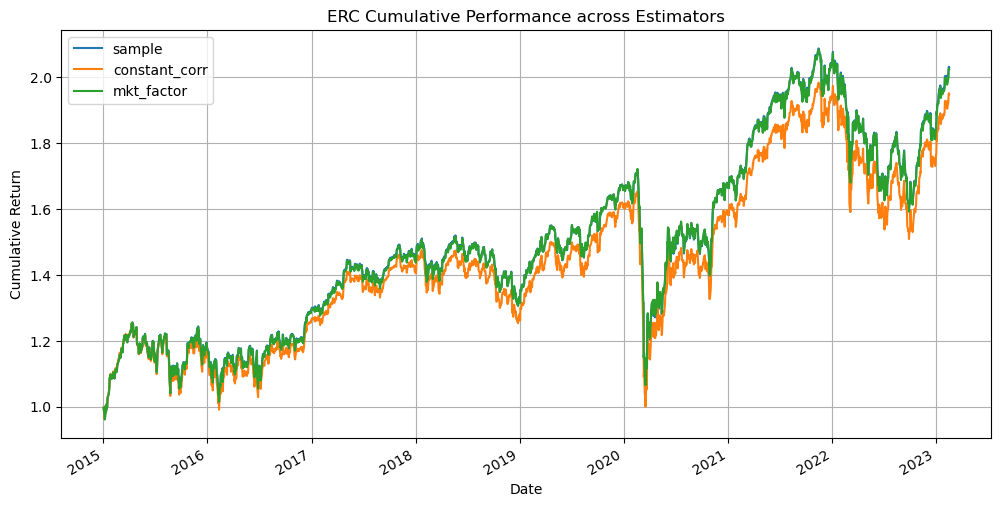

--- Part 1.c ERC Performance Summary ---
               Total Return  Avg 63d EWM Vol  Max Drawdown  \
sample             1.028268         0.170749     -0.383561   
constant_corr      0.946737         0.174137     -0.395003   
mkt_factor         1.022412         0.170156     -0.381121   

               Avg Monthly Turnover  
sample                     0.021980  
constant_corr              0.020012  
mkt_factor                 0.022377  


In [46]:
erc_portfolios = {"sample": {}, "constant_corr": {}, "mkt_factor": {}}

for reb in all_dates:
    for est_name, cov in covariances[reb].items():
        erc_portfolios[est_name][reb] = pd.Series(
            equal_risk_contribution_portfolio(cov.values),
            index=cov.index,
            name=reb,
        )

for est_name in erc_portfolios:
    # Get the universe (assets) for each rebalance date to align properly
    portfolio_list = []
    for reb, series in sorted(erc_portfolios[est_name].items()):
        # Align each series to the full performance.columns, filling missing with 0
        aligned = series.reindex(performance.columns, fill_value=0.0)
        portfolio_list.append(aligned)
    # Stack into DataFrame with rebalance dates as rows
    erc_portfolios[est_name] = pd.DataFrame(portfolio_list, index=sorted(erc_portfolios[est_name].keys()))

erc_backtests = {
    est_name: backtest(portfolios, performance)
    for est_name, portfolios in erc_portfolios.items()
}

erc_backtests = pd.DataFrame(erc_backtests)

plt.figure(figsize=(12, 6))
erc_backtests.plot(ax=plt.gca())
plt.title("ERC Cumulative Performance across Estimators")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

summary_stats = pd.DataFrame(index=erc_backtests.columns)

# 1. Cumulative Return
summary_stats['Total Return'] = erc_backtests.iloc[-1] - 1

# 2. 63d EWM Volatility (Annualized)
# Note: we use returns here, not the cumulative backtest
returns_df = erc_backtests.pct_change()
ann_factor = np.sqrt(252)
summary_stats['Avg 63d EWM Vol'] = returns_df.ewm(span=63).std().mean() * ann_factor

# 3. Maximum Drawdown
rolling_max = erc_backtests.cummax()
drawdowns = (erc_backtests - rolling_max) / rolling_max
summary_stats['Max Drawdown'] = drawdowns.min()

# 4. Average Turnover
# Computed from the weight dataframes created in Cell 7
for est_name in erc_portfolios:
    weights = erc_portfolios[est_name]
    turnover = weights.diff().abs().sum(axis=1).mean()
    summary_stats.loc[est_name, 'Avg Monthly Turnover'] = turnover

print("--- Part 1.c ERC Performance Summary ---")
print(summary_stats)

## Part II — Hierarchical Risk Parity (HRP)


### 2.a Detoning — intuition



--- Before Detoning ---


/Users/filippo/Desktop/Assignment_4b_RM_Fineng/utilities/hierarchical_clustering.py:30: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(


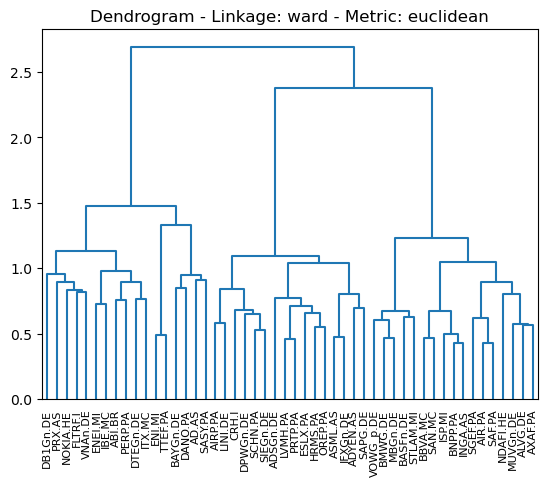

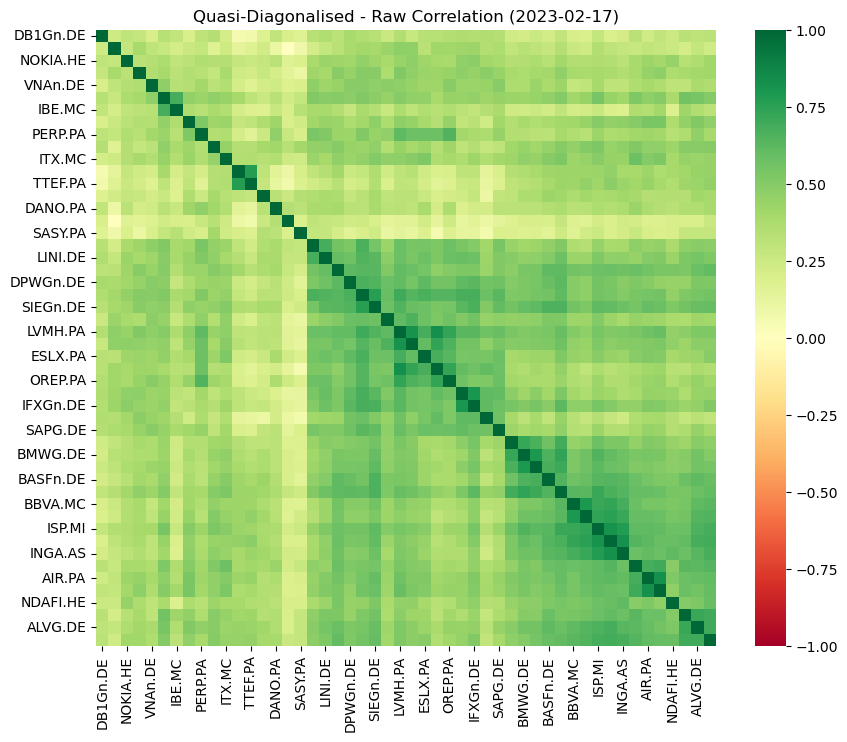


--- After Detoning ---


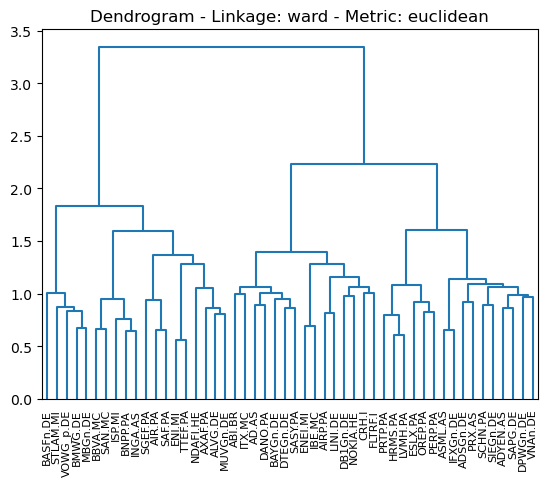

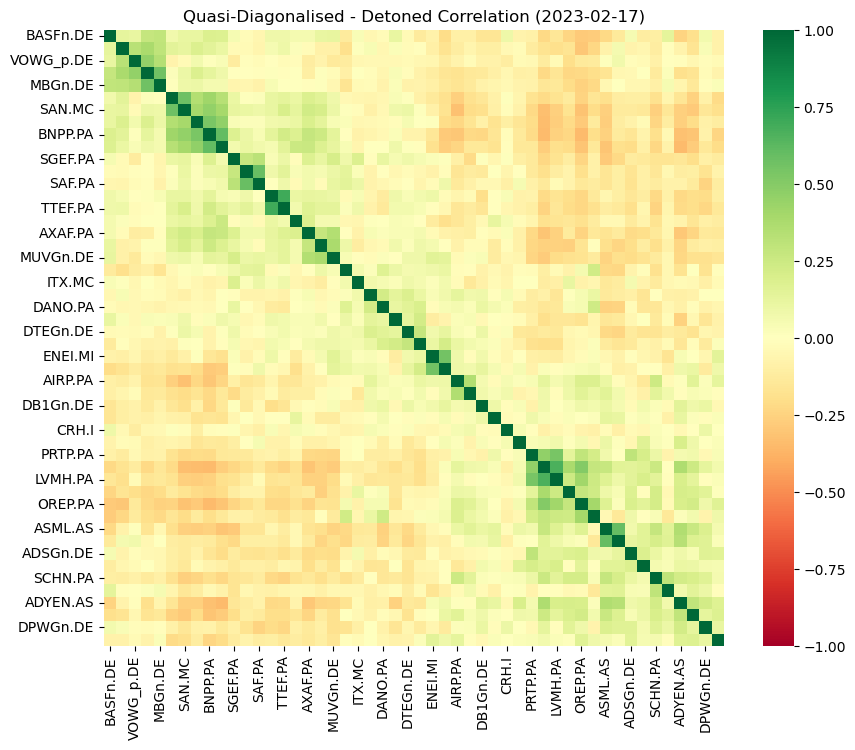

In [47]:
import seaborn as sns

print("\n--- Before Detoning ---")

# Select the last rebalance date
last_date = all_dates[-1]

# Compute the correlation matrix at last rebalancing date
cov_matrix_last_date = covariances[last_date]["sample"]
corr_matrix_raw = covariance_to_correlation(cov_matrix_last_date.values)

labels = cov_matrix_last_date.index.tolist()
corr_matrix_raw_df = pd.DataFrame(corr_matrix_raw, index=labels, columns=labels)

# Calculate distances
dist_raw_df = pd.DataFrame(
    correlation_to_hrp_distance(corr_matrix_raw_df.values), index=labels, columns=labels
)



linkage_sample_raw = hierarchical_clustering( matrix = dist_raw_df,
                                                linkage_method = "ward",
                                                distance_metric = "euclidean",
                                                plot_dendrogram = True
                                                )


leaves_raw = sch.leaves_list(linkage_sample_raw.values)
corr_raw_quasi_diag = corr_matrix_raw_df.iloc[leaves_raw, leaves_raw]

plt.figure(figsize=(10, 8))
sns.heatmap(corr_raw_quasi_diag, cmap="RdYlGn", vmin=-1, vmax=1)
plt.title(f"Quasi-Diagonalised - Raw Correlation ({last_date.strftime('%Y-%m-%d')})")
plt.show()




# Now repeat the procedure for the detoned matrix
print("\n--- After Detoning ---")

corr_matrix_detoned = detone( corr_matrix = corr_matrix_raw , components_num = 1 )
corr_matrix_detoned_df = pd.DataFrame(corr_matrix_detoned, index=labels, columns=labels)

dist_detoned_df = pd.DataFrame(
    correlation_to_hrp_distance(corr_matrix_detoned_df.values), index=labels, columns=labels
)

linkage_sample_detoned = hierarchical_clustering( matrix = dist_detoned_df,
                                                linkage_method = "ward",
                                                distance_metric = "euclidean",
                                                plot_dendrogram = True
                                                )

leaves_detoned = sch.leaves_list(linkage_sample_detoned.values)
corr_detoned_quasi_diag = corr_matrix_detoned_df.iloc[leaves_detoned, leaves_detoned]

plt.figure(figsize=(10, 8))
sns.heatmap(corr_detoned_quasi_diag, cmap="RdYlGn", vmin=-1, vmax=1)
plt.title(f"Quasi-Diagonalised - Detoned Correlation ({last_date.strftime('%Y-%m-%d')})")
plt.show()

### 2.c Cluster stability across rebalances (Rand index)

We measure how stable the clustering is between consecutive rebalances via the Rand index. A value close to 1 means the partition into $k$ clusters changes little month-to-month.


/Users/filippo/Desktop/Assignment_4b_RM_Fineng/utilities/hierarchical_clustering.py:30: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/filippo/Desktop/Assignment_4b_RM_Fineng/utilities/hierarchical_clustering.py:30: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/filippo/Desktop/Assignment_4b_RM_Fineng/utilities/hierarchical_clustering.py:30: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/filippo/Desktop/Assignment_4b_RM_Fineng/utilities/hierarchical_clustering.py:30: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/filippo/Desktop/A

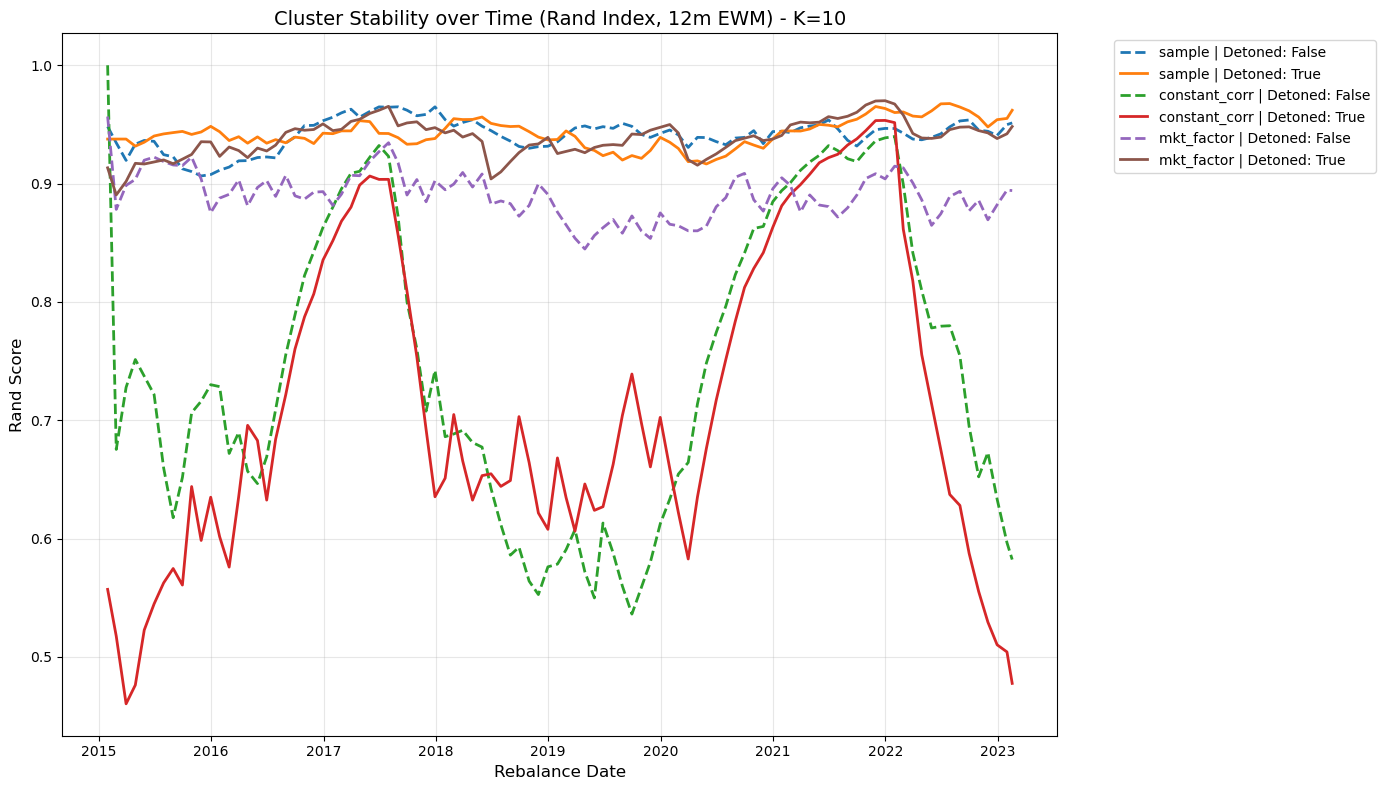

In [48]:
LINKAGE_METHOD = "ward"
DIST_METRIC = "euclidean"
N_CLUSTERS_GRID = [5, 8, 10, 15]
N_CLUSTERS_FOCUS = 10
COV_KEYS = ["sample", "constant_corr", "mkt_factor"]
DETONE_KEYS = [False, True]


linkages = {(c, d): {} for c in COV_KEYS for d in DETONE_KEYS}
clusters = {
    (c, d, k): {} for c in COV_KEYS for d in DETONE_KEYS for k in N_CLUSTERS_GRID
}


for reb in all_dates:
    for cov_key in COV_KEYS:
        cov = covariances[reb][cov_key]
        for detone_flag in DETONE_KEYS:



            corr = covariance_to_correlation(cov.values)
            corr_df = pd.DataFrame(corr, index=cov.index, columns=cov.columns)
            
            if detone_flag:
                corr_df = detone(corr_matrix=corr_df, components_num=1)
            
            dist_df = pd.DataFrame(correlation_to_hrp_distance(corr_df.values), index=cov.index, columns=cov.columns)

            link = hierarchical_clustering( matrix = dist_df,
                                            linkage_method = LINKAGE_METHOD,
                                            distance_metric = DIST_METRIC,
                                            plot_dendrogram = False,
                                            )



            linkages[(cov_key, detone_flag)][reb] = link
            for n_clusters in N_CLUSTERS_GRID:
                clusters[(cov_key, detone_flag, n_clusters)][reb] = pd.Series(
                    sch.cut_tree(link.values, n_clusters=n_clusters).flatten(),
                    index=cov.index,
                )




rand_indices = {
    (c, d, k): pd.Series(index=all_dates, dtype=float)
    for c in COV_KEYS for d in DETONE_KEYS for k in N_CLUSTERS_GRID
}

for c in COV_KEYS:
    for d in DETONE_KEYS:
        for k in N_CLUSTERS_GRID:
            
            for i in range(1, len(all_dates)):
                curr_date = all_dates[i]
                prev_date = all_dates[i-1]

                labels_curr = clusters[(c, d, k)][curr_date]
                labels_prev = clusters[(c, d, k)][prev_date]

                aligned_prev, aligned_curr = labels_prev.align(labels_curr, join='inner')

                score = rand_score(aligned_prev, aligned_curr)
                rand_indices[(c, d, k)][curr_date] = score 


k_focus = N_CLUSTERS_FOCUS

plt.figure(figsize=(14, 8))

for c in COV_KEYS:
    for d in DETONE_KEYS:
        # Estraiamo la serie, eliminando il primo valore (che è NaN perché non c'è un t-1)
        ts_raw = rand_indices[(c, d, k_focus)].dropna()
        
        # Applichiamo la media mobile esponenziale (EWM) a 12 periodi (mesi)
        ts_smoothed = ts_raw.ewm(span=12).mean()
        
        # Definiamo le etichette e lo stile per il grafico
        # Linea continua se detoned=True, tratteggiata se detoned=False
        label_str = f"{c} | Detoned: {d}"
        linestyle = '-' if d else '--'
        
        # Tracciamo la linea
        plt.plot(ts_smoothed.index, ts_smoothed.values, label=label_str, linestyle=linestyle, linewidth=2)


# Formattazione del grafico
plt.title(f"Cluster Stability over Time (Rand Index, 12m EWM) - K={k_focus}", fontsize=14)
plt.xlabel("Rebalance Date", fontsize=12)
plt.ylabel("Rand Score", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Sposta la legenda fuori dal grafico
plt.grid(True, alpha=0.3)
plt.tight_layout() # Ottimizza gli spazi

# Mostriamo il grafico
plt.show()

### 2.d Sensitivity of HRP weights — clustering vs. allocation traversal


In [49]:
LINK_GRID = ["single", "ward", "complete", "average"]
ALLOC_GRID = {
    "recursive_bisection": recursive_bisection,
    "dendrogram_iteration": dendrogram_iteration,
}

hrp_grid = {}
for cov_key in COV_KEYS:
    for link in LINK_GRID:
        for alloc_name, alloc in ALLOC_GRID.items():
            for d in DETONE_KEYS:

                
                weights = []

                for reb in all_dates:

                    w = hierarchical_risk_parity(
                        covariance=covariances[reb][cov_key],
                        linkage_method=link,
                        distance_metric=DIST_METRIC,
                        cluster_traverser=alloc,
                        perform_detoning=d,
                    )

                    w.name = reb
                    weights.append(w)
                
                hrp_grid[(cov_key, link, alloc_name, d)] = pd.concat(weights, axis=1).T



# queste due funzioni possiamo metterle in un file py già esistente, o crearne uno noi, poi diciamolo nel report

def compute_mean_herfindahl(weights_df: pd.DataFrame) -> float:
    """
    Calcola la media temporale dell'Indice di Herfindahl.
    Formula: Somma dei quadrati dei pesi in un dato periodo, mediata su tutti i periodi.
    """
    return (weights_df ** 2).sum(axis=1).mean()

def compute_mean_turnover(weights_df: pd.DataFrame) -> float:
    """
    Calcola la media temporale del turnover.
    Formula: Somma delle variazioni assolute dei pesi rispetto al periodo precedente, mediata nel tempo.
    """
    # .diff() calcola w(t) - w(t-1)
    # .abs() prende il valore assoluto della variazione
    # .sum(axis=1) somma le variazioni di tutti gli asset per una singola data
    return weights_df.diff().abs().sum(axis=1).mean()



# 2. Creiamo una lista per raccogliere i risultati di tutte le varianti
summary_results = []

# 3. Iteriamo sulla griglia che hai appena calcolato
for keys, weights_df in hrp_grid.items():
    cov_key, link, alloc_name, detone_flag = keys
    
    # Calcoliamo le due metriche per questo specifico DataFrame di pesi
    mean_hhi = compute_mean_herfindahl(weights_df)
    mean_turn = compute_mean_turnover(weights_df)
    
    # Aggiungiamo i risultati al nostro raccoglitore
    summary_results.append({
        "Covariance Estimator": cov_key,
        "Linkage Method": link,
        "Allocation Method": alloc_name,
        "Detoning": detone_flag,
        "Mean Turnover": mean_turn,
        "Mean Herfindahl": mean_hhi
    })

# 4. Trasformiamo i risultati in un DataFrame per una visualizzazione chiara
summary_df = pd.DataFrame(summary_results)

# 5. Stampiamo la tabella ordinandola per Turnover e Herfindahl crescenti
# (i valori più bassi indicano maggiore stabilità e migliore diversificazione)
# Se i valori di Mean Turnover fossero identici tra due righe, Pandas userebbe Mean Herfindahl come secondo criterio di ordinamento.
print("\n--- Sensitività dei pesi HRP (Punto 2d) ---")
display(summary_df.sort_values(by=["Mean Turnover", "Mean Herfindahl"]).reset_index(drop=True))

/Users/filippo/Desktop/Assignment_4b_RM_Fineng/utilities/hierarchical_clustering.py:30: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/filippo/Desktop/Assignment_4b_RM_Fineng/utilities/hierarchical_clustering.py:30: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/filippo/Desktop/Assignment_4b_RM_Fineng/utilities/hierarchical_clustering.py:30: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/filippo/Desktop/Assignment_4b_RM_Fineng/utilities/hierarchical_clustering.py:30: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(
/Users/filippo/Desktop/A


--- Sensitività dei pesi HRP (Punto 2d) ---


/Users/filippo/Desktop/Assignment_4b_RM_Fineng/utilities/hierarchical_clustering.py:30: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = sch.linkage(


,Covariance Estimator,Linkage Method,Allocation Method,Detoning,Mean Turnover,Mean Herfindahl
0,mkt_factor,single,dendrogram_iteration,False,0.198289,0.287266
1,sample,single,dendrogram_iteration,False,0.244546,0.203587
2,constant_corr,single,recursive_bisection,False,0.251948,0.065454
3,constant_corr,complete,recursive_bisection,False,0.311627,0.064161
4,sample,ward,recursive_bisection,True,0.330669,0.065952
5,sample,average,recursive_bisection,True,0.331749,0.066126
6,mkt_factor,single,recursive_bisection,False,0.332664,0.072722
7,sample,average,recursive_bisection,False,0.333756,0.068674
8,sample,ward,recursive_bisection,False,0.339512,0.067929
9,mkt_factor,single,recursive_bisection,True,0.340530,0.074356


## Part III — Connecting the Dots


### 3.a ERC vs HRP — Robustness Against Estimator Choice

In [50]:
# The three pairs of estimators to compare
estimator_pairs = [
    ("sample",        "constant_corr"),
    ("sample",        "mkt_factor"),
    ("constant_corr", "mkt_factor"),
]

# Representative HRP configuration chosen from Part II.d analysis:
# Ward linkage produces the most balanced and stable clusters.
# Dendrogram iteration follows the actual hierarchy.
# Detoning is enabled to remove the market-mode bias before clustering.
HRP_LINK  = "ward"
HRP_ALLOC = "dendrogram_iteration"
HRP_DETONE = True

print("--- Average L1 Distance across Covariance Estimators ---\n")

for est1, est2 in estimator_pairs:

    # ── ERC robustness ────────────────────────────────────────────────────────
    # erc_portfolios DataFrames are already aligned to performance.columns,
    # so the subtraction is safe as-is.
    w1_erc = erc_portfolios[est1].fillna(0.0)
    w2_erc = erc_portfolios[est2].fillna(0.0)

    l1_erc = (w1_erc - w2_erc).abs().sum(axis=1).mean()

    # ── HRP robustness ────────────────────────────────────────────────────────
    # align both DataFrames to the union of their columns before
    # subtracting
    w1_hrp = hrp_grid[(est1, HRP_LINK, HRP_ALLOC, HRP_DETONE)].fillna(0.0)
    w2_hrp = hrp_grid[(est2, HRP_LINK, HRP_ALLOC, HRP_DETONE)].fillna(0.0)

    all_cols_hrp = w1_hrp.columns.union(w2_hrp.columns)
    w1_hrp = w1_hrp.reindex(columns=all_cols_hrp, fill_value=0.0)
    w2_hrp = w2_hrp.reindex(columns=all_cols_hrp, fill_value=0.0)

    l1_hrp = (w1_hrp - w2_hrp).abs().sum(axis=1).mean()

    print(f"Estimators: [{est1:^14}] vs [{est2:^14}]")
    print(f"  - ERC L1 Distance: {l1_erc:.4f}")
    print(f"  - HRP L1 Distance: {l1_hrp:.4f}\n")

--- Average L1 Distance across Covariance Estimators ---

Estimators: [    sample    ] vs [constant_corr ]
  - ERC L1 Distance: 0.0964
  - HRP L1 Distance: 1.2206

Estimators: [    sample    ] vs [  mkt_factor  ]
  - ERC L1 Distance: 0.0194
  - HRP L1 Distance: 1.4703

Estimators: [constant_corr ] vs [  mkt_factor  ]
  - ERC L1 Distance: 0.1032
  - HRP L1 Distance: 1.5631



### 3.b ERC vs HRP — performance, vol, drawdown, turnover


--- Part 3.b Performance Summary ---

Metric                                  ERC          HRP
--------------------------------------------------------
Total Cumulative Return             102.83%      130.81%
Avg Annualised Vol (63d EWM)         17.06%       29.54%
Maximum Drawdown                    -38.36%      -55.34%
Avg Monthly Turnover                  2.20%       53.71%


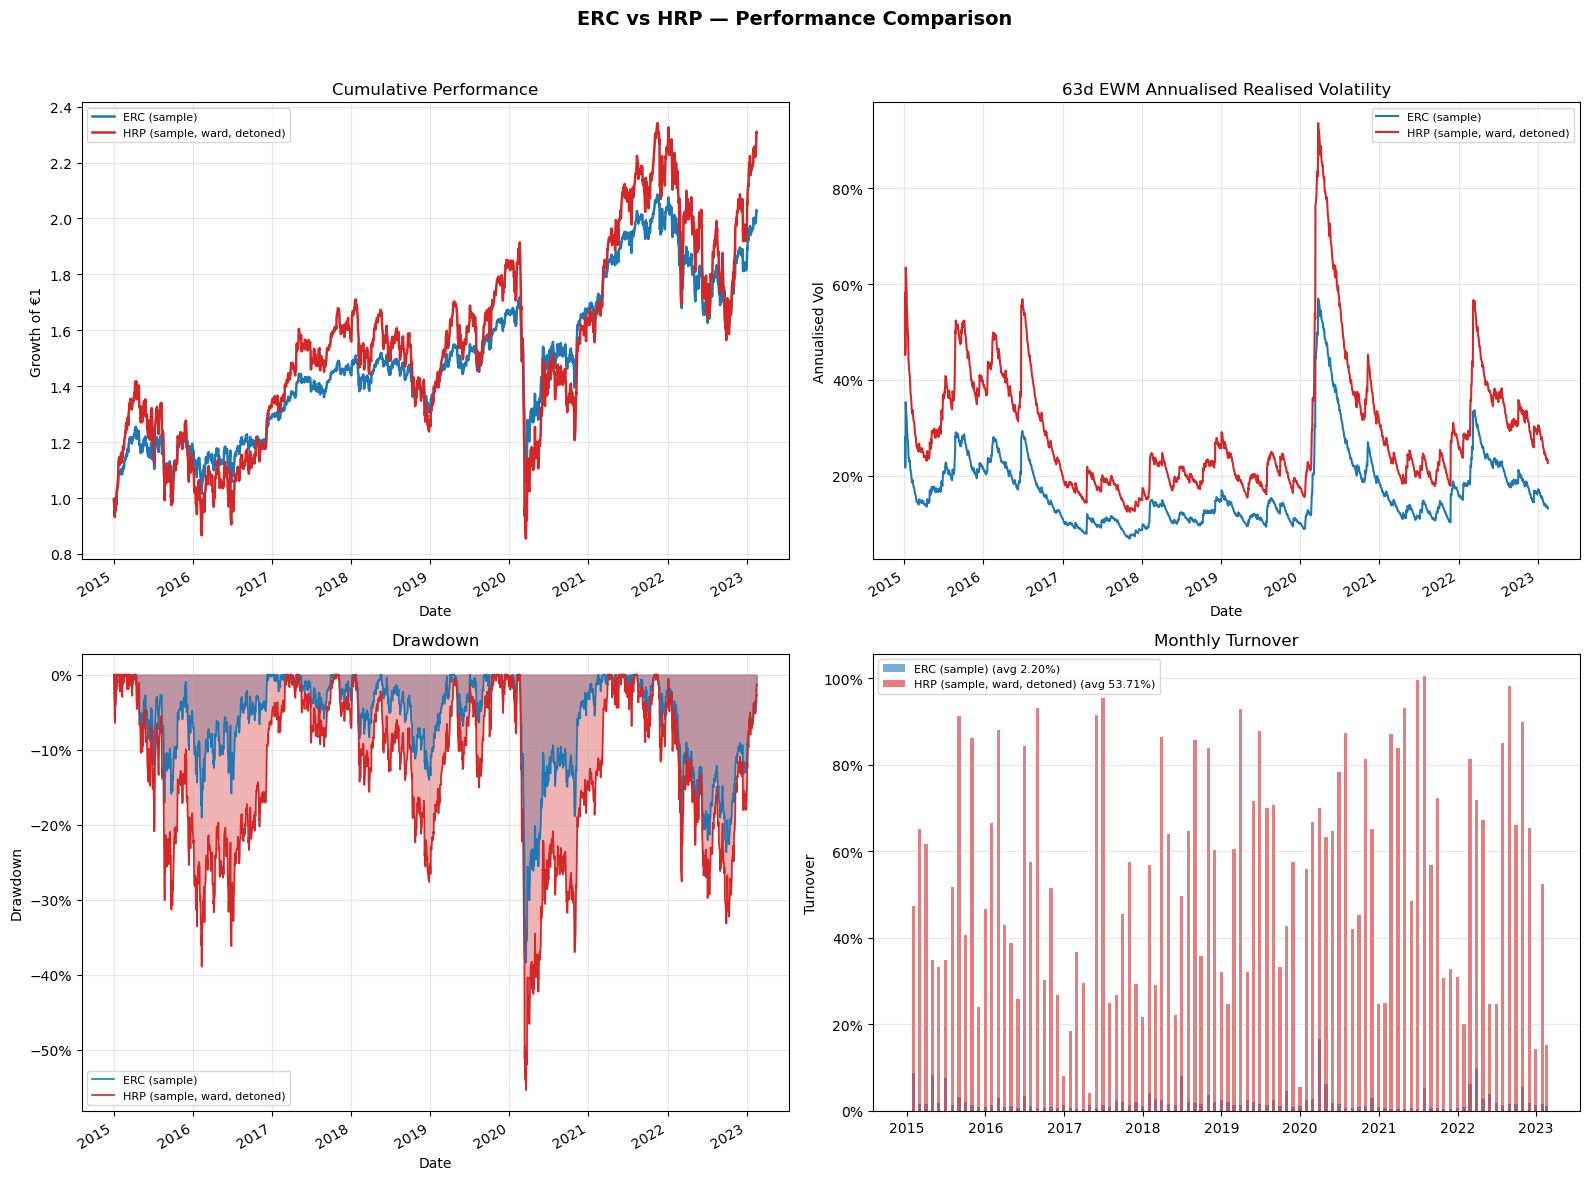

In [51]:
from matplotlib.ticker import PercentFormatter

REP_ESTIMATOR = "sample"

# Extract weight schedules (monthly, indexed by rebalance dates)
w_erc_rep = erc_portfolios[REP_ESTIMATOR]
w_hrp_rep = hrp_grid[(REP_ESTIMATOR, HRP_LINK, HRP_ALLOC, HRP_DETONE)]

# Daily realized portfolio returns (gross of transaction costs)
ret_erc = portfolio_returns(portfolios=w_erc_rep, returns=performance)
ret_hrp = portfolio_returns(portfolios=w_hrp_rep, returns=performance)

# --- 1. Cumulative performance ---
cum_erc = (1.0 + ret_erc).cumprod()
cum_hrp = (1.0 + ret_hrp).cumprod()

# --- 2. 63d EWM annualised realized volatility ---
# ann_factor = sqrt(252) is already defined in Part I.
# span=63 ≈ 3 months of trading days.
vol_erc = ret_erc.ewm(span=63).std() * ann_factor
vol_hrp = ret_hrp.ewm(span=63).std() * ann_factor

# --- 3. Drawdown ---
dd_erc = (cum_erc - cum_erc.cummax()) / cum_erc.cummax()
dd_hrp = (cum_hrp - cum_hrp.cummax()) / cum_hrp.cummax()

# --- 4. Monthly one-way turnover ---
# Convention used:
#   turnover = sum_i |w_i(t) - w_i(t-1)|  
turn_erc = w_erc_rep.fillna(0.0).diff().abs().sum(axis=1).mean()
turn_hrp = w_hrp_rep.fillna(0.0).diff().abs().sum(axis=1).mean()

# --- Summary table ---
print("--- Part 3.b Performance Summary ---\n")
print(f"{'Metric':<30} {'ERC':>12} {'HRP':>12}")
print("-" * 56)
print(f"{'Total Cumulative Return':<30} {cum_erc.iloc[-1]-1:>12.2%} {cum_hrp.iloc[-1]-1:>12.2%}")
print(f"{'Avg Annualised Vol (63d EWM)':<30} {vol_erc.mean():>12.2%} {vol_hrp.mean():>12.2%}")
print(f"{'Maximum Drawdown':<30} {dd_erc.min():>12.2%} {dd_hrp.min():>12.2%}")
print(f"{'Avg Monthly Turnover':<30} {turn_erc:>12.2%} {turn_hrp:>12.2%}")

# --- Plotting section ---
LABEL_ERC = f"ERC ({REP_ESTIMATOR})"
LABEL_HRP = f"HRP ({REP_ESTIMATOR}, {HRP_LINK}, detoned)"
C_ERC, C_HRP = "#1f77b4", "#d62728"
colors = [C_ERC, C_HRP]

df_cum = pd.DataFrame({LABEL_ERC: cum_erc, LABEL_HRP: cum_hrp})
df_vol = pd.DataFrame({LABEL_ERC: vol_erc, LABEL_HRP: vol_hrp})
df_dd  = pd.DataFrame({LABEL_ERC: dd_erc,  LABEL_HRP: dd_hrp})

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("ERC vs HRP — Performance Comparison", fontsize=14, fontweight="bold")

# Panel 1: Cumulative performance
df_cum.plot(ax=axes[0, 0], color=colors, lw=1.8,
            title="Cumulative Performance", ylabel="Growth of €1")

# Panel 2: 63d EWM annualised volatility
df_vol.plot(ax=axes[0, 1], color=colors, lw=1.5,
            title="63d EWM Annualised Realised Volatility", ylabel="Annualised Vol")

# Panel 3: Drawdown
df_dd.plot(ax=axes[1, 0], color=colors, lw=1.2,
           title="Drawdown", ylabel="Drawdown")
axes[1, 0].fill_between(dd_erc.index, dd_erc.values, 0, alpha=0.35, color=C_ERC)
axes[1, 0].fill_between(dd_hrp.index, dd_hrp.values, 0, alpha=0.35, color=C_HRP)

# Panel 4: Monthly turnover bar chart (FIX 3 applied here too — no / 2.0)
turn_series_erc = w_erc_rep.fillna(0.0).diff().abs().sum(axis=1).dropna()
turn_series_hrp = w_hrp_rep.fillna(0.0).diff().abs().sum(axis=1).dropna()

axes[1, 1].bar(
    turn_series_erc.index, turn_series_erc.values,
    width=15, alpha=0.6, color=C_ERC,
    label=f"{LABEL_ERC} (avg {turn_erc:.2%})",
)
axes[1, 1].bar(
    turn_series_hrp.index, turn_series_hrp.values,
    width=15, alpha=0.6, color=C_HRP,
    label=f"{LABEL_HRP} (avg {turn_hrp:.2%})",
)
axes[1, 1].set_title("Monthly Turnover")
axes[1, 1].set_ylabel("Turnover")

# Common styling: legend, grid, percentage formatter on vol/dd/turnover panels
pct_formatter = PercentFormatter(1.0, decimals=0)
for i, ax in enumerate(axes.flat):
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis="y" if i == 3 else "both")
    if i in [1, 2, 3]:   # vol, drawdown, turnover — all percentage axes
        ax.yaxis.set_major_formatter(pct_formatter)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
